# Crops Dataset Visualisation
Dataset: the crop directory of the private institutional cohort, located via `$DP_NOU_ROOT`.  
206 TIFF crops from 28 patients with labels encoded in filenames.

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tifffile

from dpcode.paths import resolve_paths

# These crops belong to the private institutional cohort. `paths.nou_root` is
# the one key in dpcode/conf/paths/default.yaml with NO committed default, so
# this notebook reads $DP_NOU_ROOT and fails loudly when it is unset instead of
# hardcoding one machine's checkout. The literal replaced here did both: it was
# machine-specific, and it named a staging directory that no longer exists.
NOU_ROOT = resolve_paths()['nou_root']
if NOU_ROOT is None:
    raise RuntimeError(
        'DP_NOU_ROOT is unset. This notebook reads a private institutional '
        'cohort, which by policy has no committed path. Export DP_NOU_ROOT to '
        'your copy of the cohort root before running this cell.'
    )

# Crop directory relative to the cohort root; override if yours is named
# differently. Nothing below reads anything outside DATASET_DIR.
CROPS_SUBDIR = os.environ.get('DP_NOU_CROPS_DIR', 'crops')
DATASET_DIR = Path(NOU_ROOT) / CROPS_SUBDIR
if not DATASET_DIR.is_dir():
    raise FileNotFoundError(
        f'{DATASET_DIR} is not a directory. The default subdirectory name is a '
        'neutral placeholder, not the cohort layout; set DP_NOU_CROPS_DIR to the '
        'name of the crop directory inside your DP_NOU_ROOT.'
    )

## 1. Parse Filenames into Metadata

In [2]:
# Filename pattern: {sample_id}-{variation}-poloha-{location}-{attr1}-{attr2}-EP-{ep}-EMT-{emt}-ANY-{any}.tiff
PATTERN = re.compile(
    r'^(?P<sample_id>\d+)-(?P<variation>\d+)-poloha-(?P<location>\d+)'
    r'-(?P<attr1>\d+)-(?P<attr2>\d+)'
    r'-EP-(?P<EP>\d+)-EMT-(?P<EMT>\d+)-ANY-(?P<ANY>\d+)\.tiff$'
)

records = []
for p in sorted(DATASET_DIR.glob('*.tiff')):
    m = PATTERN.match(p.name)
    if m:
        d = m.groupdict()
        d['path'] = p
        d['filename'] = p.name
        records.append(d)
    else:
        print(f'No match: {p.name}')

df = pd.DataFrame(records)
for col in ['sample_id', 'variation', 'location', 'attr1', 'attr2', 'EP', 'EMT', 'ANY']:
    df[col] = df[col].astype(int)

print(f"Total crops : {len(df)}")
print(f"Unique patients: {df['sample_id'].nunique()}")
df.head()

Total crops : 206
Unique patients: 28


,sample_id,variation,location,attr1,attr2,EP,EMT,ANY,path,filename
0,1005137,0,537,1,0,0,0,0,/workspace/dp-code/.datasets/extracted_nou/cro...,1005137-0-poloha-537-1-0-EP-0-EMT-0-ANY-0.tiff
1,1005137,2,539,1,1,0,0,0,/workspace/dp-code/.datasets/extracted_nou/cro...,1005137-2-poloha-539-1-1-EP-0-EMT-0-ANY-0.tiff
2,1005137,3,540,1,1,0,0,0,/workspace/dp-code/.datasets/extracted_nou/cro...,1005137-3-poloha-540-1-1-EP-0-EMT-0-ANY-0.tiff
3,1005137,4,541,1,1,0,0,0,/workspace/dp-code/.datasets/extracted_nou/cro...,1005137-4-poloha-541-1-1-EP-0-EMT-0-ANY-0.tiff
4,1005137,5,542,1,1,0,0,0,/workspace/dp-code/.datasets/extracted_nou/cro...,1005137-5-poloha-542-1-1-EP-0-EMT-0-ANY-0.tiff


## 2. Label Distributions

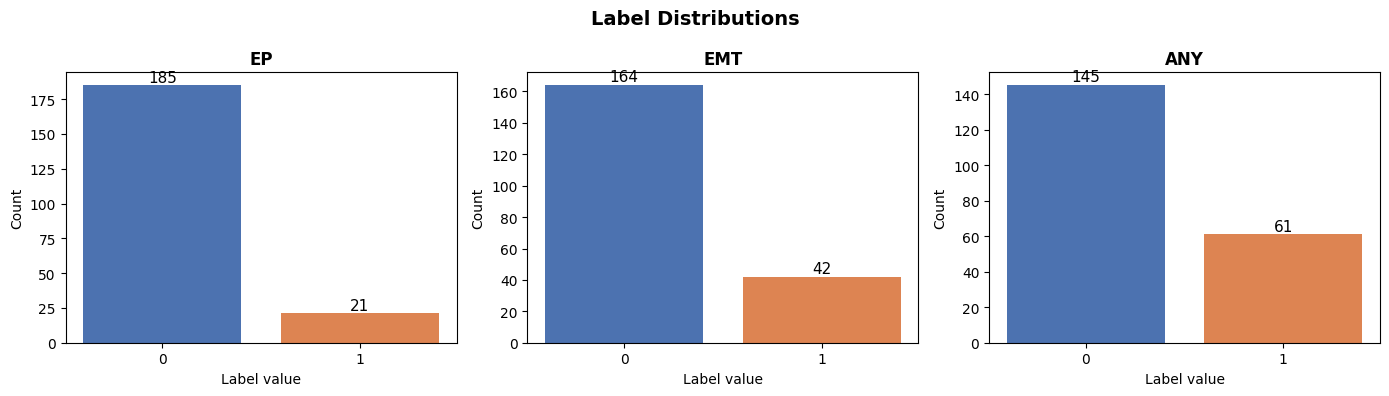

In [3]:
label_cols = ['EP', 'EMT', 'ANY']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Label Distributions', fontsize=14, fontweight='bold')

for ax, col in zip(axes, label_cols):
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'][:len(counts)])
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Label value')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                str(v), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## 3. Crops Per Patient

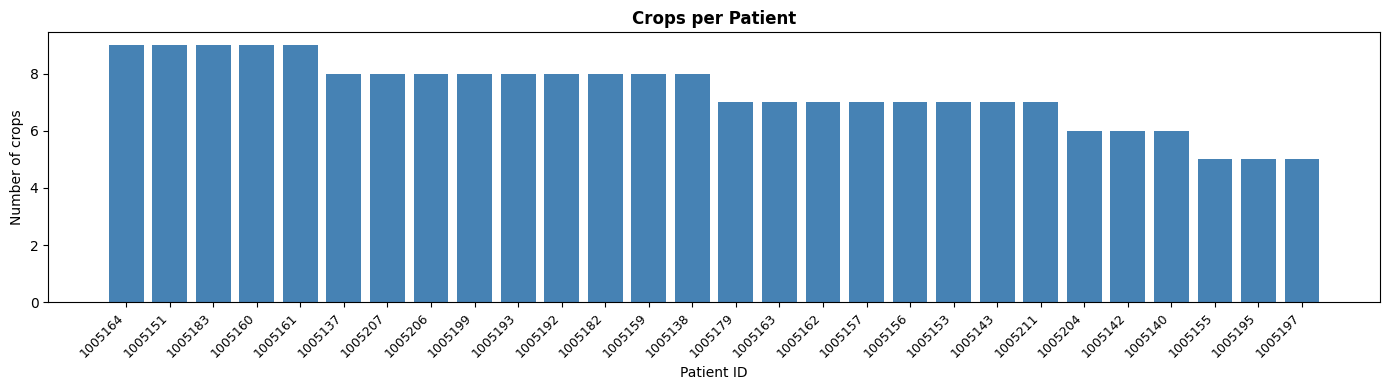

Min: 5  |  Max: 9  |  Median: 8


In [4]:
crops_per_patient = df.groupby('sample_id').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(crops_per_patient)), crops_per_patient.values, color='steelblue')
ax.set_xticks(range(len(crops_per_patient)))
ax.set_xticklabels(crops_per_patient.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Patient ID')
ax.set_ylabel('Number of crops')
ax.set_title('Crops per Patient', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Min: {crops_per_patient.min()}  |  Max: {crops_per_patient.max()}  |  Median: {crops_per_patient.median():.0f}")

## 4. Label Distribution Per Patient

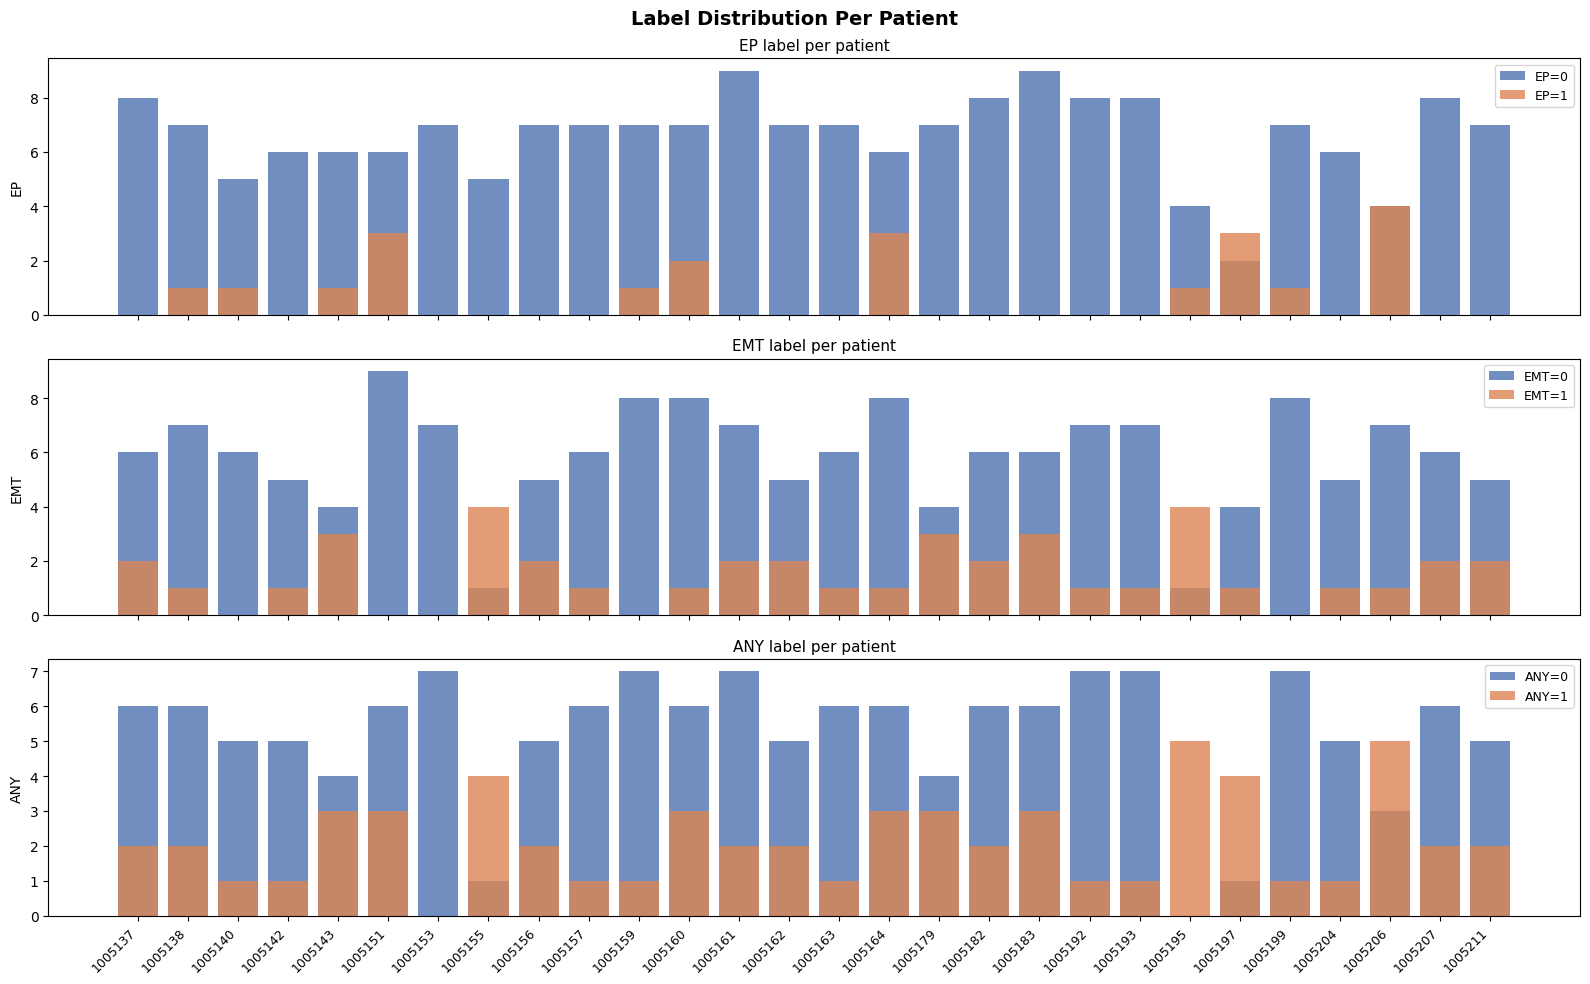

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Label Distribution Per Patient', fontsize=14, fontweight='bold')

patients = sorted(df['sample_id'].unique())
x = np.arange(len(patients))

for ax, col in zip(axes, label_cols):
    for val, color in zip(sorted(df[col].unique()), ['#4C72B0', '#DD8452', '#55A868', '#C44E52']):
        counts = [df[(df['sample_id'] == p) & (df[col] == val)].shape[0] for p in patients]
        ax.bar(x, counts, label=f'{col}={val}', color=color, alpha=0.8)
    ax.set_ylabel(col)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_title(f'{col} label per patient', fontsize=11)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(patients, rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Inspect a Single TIFF (Channels & Stats)

In [6]:
sample_path = df.iloc[0]['path']
img = tifffile.imread(sample_path)

print(f"File     : {sample_path.name}")
print(f"Shape    : {img.shape}")
print(f"Dtype    : {img.dtype}")
print(f"Min/Max  : {img.min():.4f} / {img.max():.4f}")
print(f"Mean/Std : {img.mean():.4f} / {img.std():.4f}")

File     : 1005137-0-poloha-537-1-0-EP-0-EMT-0-ANY-0.tiff
Shape    : (7641, 7342, 3)
Dtype    : uint8
Min/Max  : 6.0000 / 255.0000


Mean/Std : 233.6360 / 23.9483


## 6. Sample Images Grid
Shows one crop per patient (first crop). If multi-channel, shows first 3 channels as RGB.

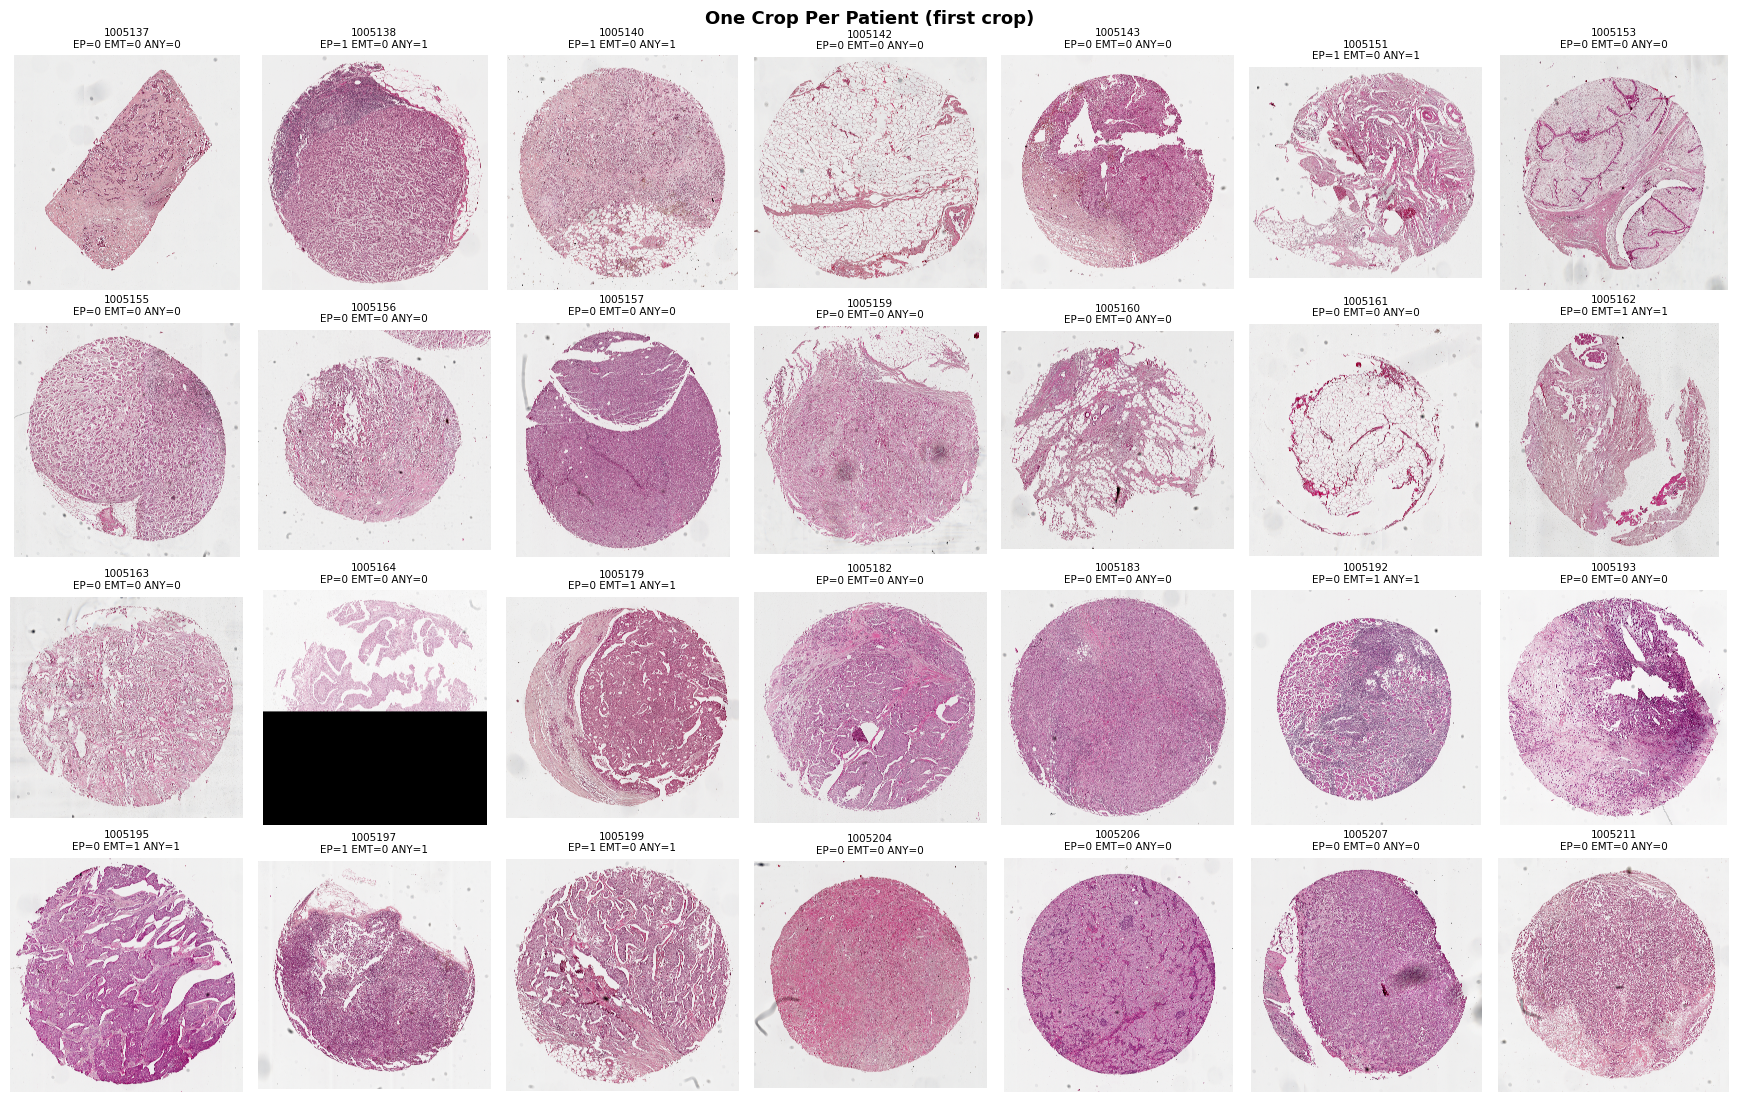

In [7]:
def load_preview(path):
    """Load TIFF and return an RGB uint8 preview."""
    img = tifffile.imread(path)
    # Handle shapes: (H,W), (H,W,C), (C,H,W)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    elif img.ndim == 3:
        if img.shape[0] <= 4 and img.shape[0] < img.shape[-1]:
            img = np.moveaxis(img, 0, -1)  # (C,H,W) -> (H,W,C)
        img = img[:, :, :3]  # take first 3 channels
    # Normalise to 0-255
    img = img.astype(np.float32)
    lo, hi = np.percentile(img, 1), np.percentile(img, 99)
    if hi > lo:
        img = np.clip((img - lo) / (hi - lo), 0, 1)
    return (img * 255).astype(np.uint8)


one_per_patient = df.groupby('sample_id').first().reset_index()
n = len(one_per_patient)
ncols = 7
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.8))
fig.suptitle('One Crop Per Patient (first crop)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, (_, row) in enumerate(one_per_patient.iterrows()):
    preview = load_preview(row['path'])
    axes[i].imshow(preview)
    axes[i].set_title(f"{row['sample_id']}\nEP={row['EP']} EMT={row['EMT']} ANY={row['ANY']}",
                      fontsize=7.5)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 7. Multiple Crops From One Patient
Shows all variations for a selected patient to see intra-patient diversity.

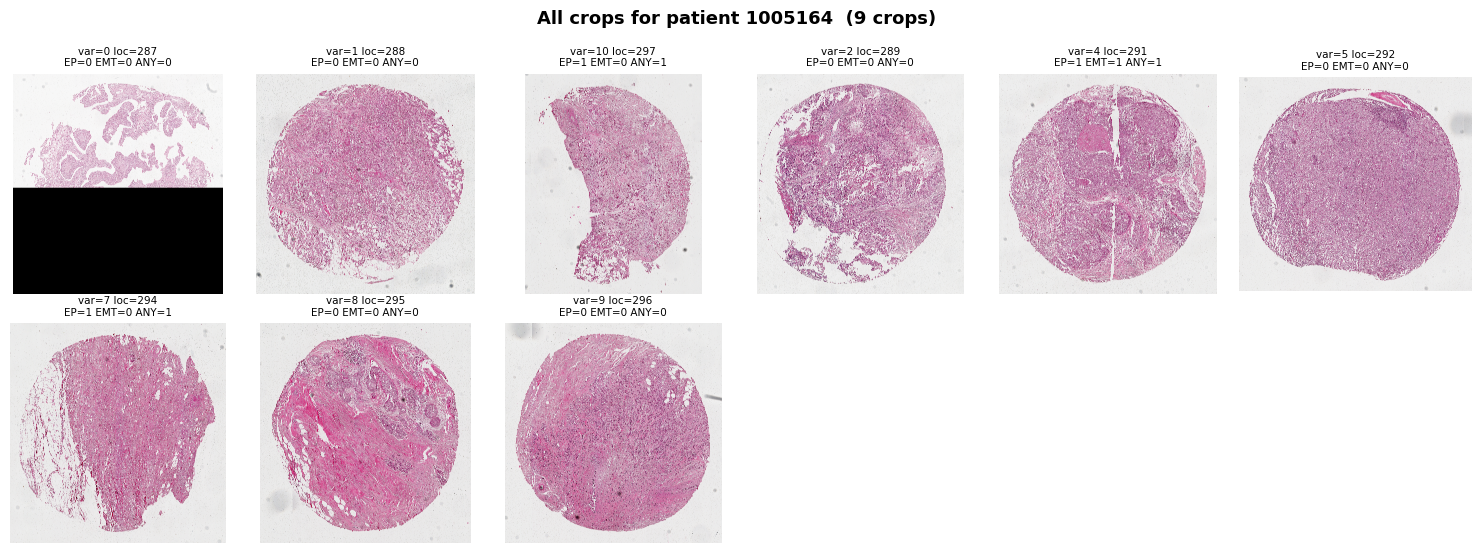

In [8]:
# Change this to any sample_id you want to inspect
PATIENT = df['sample_id'].value_counts().idxmax()  # patient with most crops

patient_df = df[df['sample_id'] == PATIENT].reset_index(drop=True)
n = len(patient_df)
ncols = min(n, 6)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.8))
fig.suptitle(f'All crops for patient {PATIENT}  ({n} crops)', fontsize=13, fontweight='bold')
axes = np.array(axes).flatten()

for i, (_, row) in enumerate(patient_df.iterrows()):
    preview = load_preview(row['path'])
    axes[i].imshow(preview)
    axes[i].set_title(
        f"var={row['variation']} loc={row['location']}\nEP={row['EP']} EMT={row['EMT']} ANY={row['ANY']}",
        fontsize=7.5
    )
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 8. Channel Statistics Across a Sample of Images

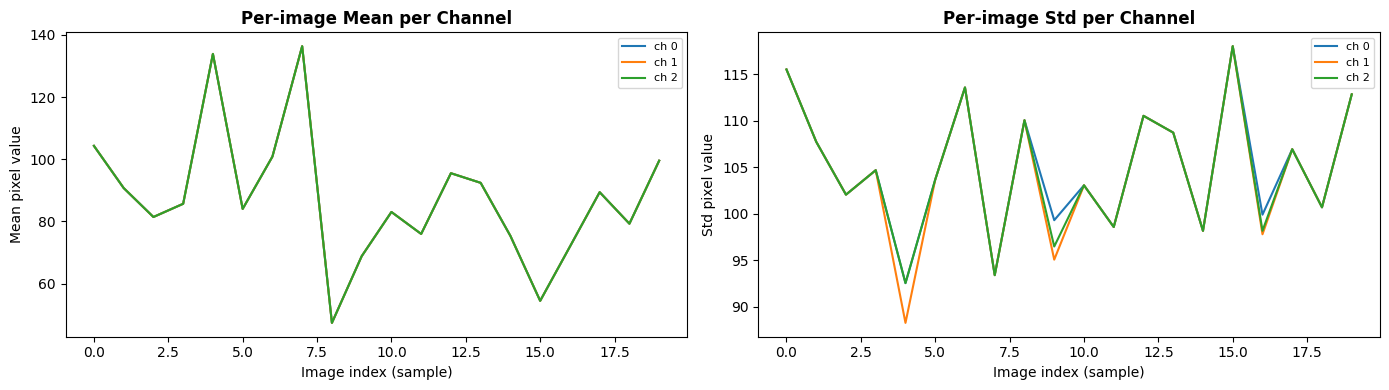

Channels: 3  |  Sampled 20 images


In [9]:
SAMPLE_N = min(20, len(df))
sample_rows = df.sample(SAMPLE_N, random_state=42)

means, stds = [], []
for _, row in sample_rows.iterrows():
    img = tifffile.imread(row['path']).astype(np.float32)
    if img.ndim == 3 and img.shape[0] <= 4:
        img = np.moveaxis(img, 0, -1)
    if img.ndim == 2:
        img = img[:, :, None]
    means.append(img.mean(axis=(0, 1)))
    stds.append(img.std(axis=(0, 1)))

means = np.array(means)  # (N, C)
stds  = np.array(stds)
n_channels = means.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for c in range(n_channels):
    axes[0].plot(means[:, c], label=f'ch {c}')
    axes[1].plot(stds[:, c], label=f'ch {c}')

axes[0].set_title('Per-image Mean per Channel', fontweight='bold')
axes[0].set_xlabel('Image index (sample)')
axes[0].set_ylabel('Mean pixel value')
axes[0].legend(fontsize=8)

axes[1].set_title('Per-image Std per Channel', fontweight='bold')
axes[1].set_xlabel('Image index (sample)')
axes[1].set_ylabel('Std pixel value')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"Channels: {n_channels}  |  Sampled {SAMPLE_N} images")

## 10. Summary Table

In [10]:
import os

# ── helpers ───────────────────────────────────────────────────────────────────

def largest_zero_block_fraction(arr2d, block_h=64, block_w=64):
    """Slide a block window and return the max fraction of zero pixels found
    in any single block — fast proxy for a large contiguous black region."""
    H, W = arr2d.shape
    best = 0.0
    step_h = max(1, block_h // 2)
    step_w = max(1, block_w // 2)
    for r in range(0, H - block_h + 1, step_h):
        for c in range(0, W - block_w + 1, step_w):
            frac = (arr2d[r:r+block_h, c:c+block_w] == 0).mean()
            if frac > best:
                best = frac
    return best


def scan_image(path):
    """Return a dict of corruption indicators for one TIFF."""
    result = dict(
        path=path,
        file_size_mb=os.path.getsize(path) / 1e6,
        read_error=None,
        shape=None,
        dtype=None,
        n_pages=None,
        global_zero_frac=None,
        max_block_zero_frac=None,
        mean=None,
        std=None,
        flagged=False,
        flag_reason='',
    )
    try:
        with tifffile.TiffFile(path) as tf:
            result['n_pages'] = len(tf.pages)
            img = tf.asarray()
    except Exception as e:
        result['read_error'] = str(e)
        result['flagged'] = True
        result['flag_reason'] = f'read_error: {e}'
        return result

    result['shape'] = img.shape
    result['dtype'] = str(img.dtype)

    # Grayscale luminance for zero-pixel analysis
    if img.ndim == 3:
        if img.shape[0] <= 4:
            img = np.moveaxis(img, 0, -1)
        gray = img[:, :, :3].mean(axis=-1).astype(np.float32)
    else:
        gray = img.astype(np.float32)

    result['mean'] = float(gray.mean())
    result['std']  = float(gray.std())

    # Normalise to uint8 for zero-detection
    if img.dtype == np.uint8:
        g8 = gray.astype(np.uint8)
    else:
        lo, hi = gray.min(), gray.max()
        g8 = ((gray - lo) / (hi - lo + 1e-9) * 255).astype(np.uint8) if hi > lo \
             else np.zeros_like(gray, dtype=np.uint8)

    global_zero = float((g8 == 0).mean())
    result['global_zero_frac'] = global_zero

    # Sub-sample for speed on large images
    scale = max(1, min(g8.shape) // 512)
    result['max_block_zero_frac'] = largest_zero_block_fraction(g8[::scale, ::scale])

    # ── flag criteria ─────────────────────────────────────────────────────────
    reasons = []
    if global_zero > 0.05:                         # >5% of image is pure black
        reasons.append(f'global_zero={global_zero:.1%}')
    if result['max_block_zero_frac'] > 0.90:       # a 64×64 block is >90% black
        reasons.append(f'block_zero={result["max_block_zero_frac"]:.1%}')
    if result['mean'] < 10:                        # whole image almost black
        reasons.append(f'mean={result["mean"]:.1f}')
    if result['n_pages'] > 1:
        reasons.append(f'multi_page={result["n_pages"]}')

    if reasons:
        result['flagged'] = True
        result['flag_reason'] = ' | '.join(reasons)

    return result


# ── run scan ──────────────────────────────────────────────────────────────────
print(f"Scanning {len(df)} images … (reads every file — may take a few minutes)")
scan_results = []
for i, (_, row) in enumerate(df.iterrows(), 1):
    r = scan_image(row['path'])
    r['filename']  = row['filename']
    r['sample_id'] = row['sample_id']
    r['variation'] = row['variation']
    r['location']  = row['location']
    scan_results.append(r)
    if i % 20 == 0:
        print(f"  {i}/{len(df)} done …")

scan_df = pd.DataFrame(scan_results)
flagged = scan_df[scan_df['flagged']].copy()

print(f"\nTotal images : {len(scan_df)}")
print(f"Flagged      : {len(flagged)}")
if len(flagged):
    display(flagged[['filename', 'sample_id', 'variation', 'location',
                      'file_size_mb', 'shape', 'n_pages',
                      'global_zero_frac', 'max_block_zero_frac',
                      'mean', 'std', 'flag_reason']].reset_index(drop=True))

Scanning 206 images … (reads every file — may take a few minutes)


  20/206 done …
  40/206 done …
  60/206 done …
  80/206 done …
  100/206 done …
  120/206 done …
  140/206 done …
  160/206 done …
  180/206 done …
  200/206 done …

Total images : 206
Flagged      : 3


,filename,sample_id,variation,location,file_size_mb,shape,n_pages,global_zero_frac,max_block_zero_frac,mean,std,flag_reason
0,1005164-0-poloha-287-1-1-EP-0-EMT-0-ANY-0.tiff,1005164,0,287,249.975404,"(9318, 8882, 3)",1.0,0.483117,1.0,117.538490,115.639397,global_zero=48.3% | block_zero=100.0%
1,1005192-3-poloha-373-1-1-EP-0-EMT-0-ANY-0.tiff,1005192,3,373,177.209344,None,NaN,NaN,NaN,NaN,NaN,read_error: not a TIFF file b'\xc3J8\x00'
2,1005199-1-poloha-467-1-1-EP-0-EMT-0-ANY-0.tiff,1005199,1,467,147.202856,"(7218, 6720, 3)",1.0,0.903510,1.0,22.525982,69.459595,global_zero=90.4% | block_zero=100.0%


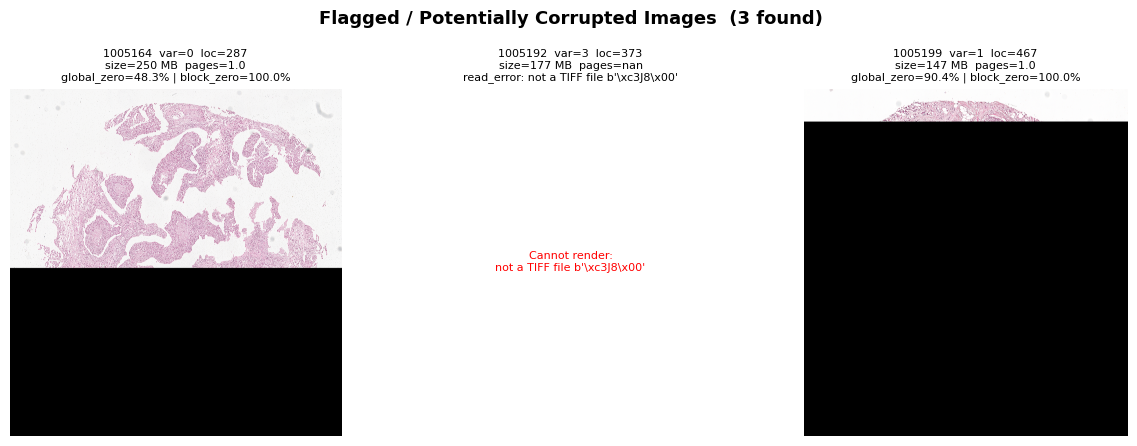

In [11]:
# ── visual inspection of all flagged images ───────────────────────────────────
if len(flagged) == 0:
    print("No flagged images — dataset looks clean.")
else:
    ncols = min(len(flagged), 4)
    nrows = (len(flagged) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4.5))
    axes = np.array(axes).flatten()
    fig.suptitle(f'Flagged / Potentially Corrupted Images  ({len(flagged)} found)',
                 fontsize=13, fontweight='bold')

    for i, (_, row) in enumerate(flagged.iterrows()):
        try:
            preview = load_preview(row['path'])
            axes[i].imshow(preview)
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Cannot render:\n{e}',
                         transform=axes[i].transAxes, ha='center', va='center',
                         fontsize=8, color='red')
        axes[i].set_title(
            f"{row['sample_id']}  var={row['variation']}  loc={row['location']}\n"
            f"size={row['file_size_mb']:.0f} MB  pages={row['n_pages']}\n"
            f"{row['flag_reason']}",
            fontsize=8
        )
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [12]:
# ── root-cause deep-dive on flagged files ────────────────────────────────────
# For each flagged image: prints TIFF internal structure (pages, tags, strip
# layout) and identifies exactly which rows/cols are zeroed out and whether
# the pattern points to an incomplete write or truncated strip.

for _, row in flagged.iterrows():
    path = row['path']
    print("=" * 70)
    print(f"FILE : {row['filename']}")
    print(f"Size : {row['file_size_mb']:.1f} MB  |  Flags: {row['flag_reason']}")

    if row['read_error']:
        print(f"  READ ERROR: {row['read_error']}")
        continue

    # TIFF metadata
    with tifffile.TiffFile(path) as tf:
        print(f"  TIFF pages  : {len(tf.pages)}")
        for pi, page in enumerate(tf.pages):
            shape       = getattr(page, 'shape', 'unknown')
            compression = getattr(page, 'compression', 'unknown')
            print(f"  Page {pi}: shape={shape}  compression={compression}")
            for tag in page.tags.values():
                if tag.name in ('ImageDescription', 'Software', 'DateTime',
                                'ImageWidth', 'ImageLength', 'BitsPerSample',
                                'SamplesPerPixel', 'RowsPerStrip',
                                'StripOffsets', 'StripByteCounts'):
                    val = tag.value
                    if isinstance(val, (tuple, list)) and len(val) > 8:
                        val = f"[{len(val)} entries]  first={val[0]}  last={val[-1]}"
                    print(f"    {tag.name:20s}: {val}")

    # Spatial analysis: which rows/cols are fully zero?
    img = tifffile.imread(path)
    if img.ndim == 3:
        if img.shape[0] <= 4:
            img = np.moveaxis(img, 0, -1)
        gray = img[:, :, :3].mean(axis=-1)
    else:
        gray = img.astype(np.float32)

    zero_rows = np.where((gray == 0).all(axis=1))[0]
    zero_cols = np.where((gray == 0).all(axis=0))[0]
    H, W = gray.shape

    print(f"  Zero-only rows: {len(zero_rows)}/{H}  "
          f"({zero_rows[:5].tolist()} … {zero_rows[-5:].tolist() if len(zero_rows) > 5 else ''})")
    print(f"  Zero-only cols: {len(zero_cols)}/{W}  "
          f"({zero_cols[:5].tolist()} … {zero_cols[-5:].tolist() if len(zero_cols) > 5 else ''})")

    if len(zero_rows) > 0:
        bottom_start = int(zero_rows.min())
        is_bottom = np.array_equal(zero_rows, np.arange(bottom_start, H))
        is_top    = np.array_equal(zero_rows, np.arange(0, int(zero_rows.max()) + 1))
        pct = len(zero_rows) / H * 100

        print(f"  Contiguous bottom block (row {bottom_start}–{H-1}): {is_bottom}")
        print(f"  Contiguous top    block (row 0–{zero_rows.max()}):   {is_top}")
        print(f"  → {pct:.1f}% of image height is zero-only rows")

        if is_bottom or is_top:
            print(f"  LIKELY CAUSE: incomplete write / truncated strip during crop extraction.")
            print(f"  The TIFF strip containing rows {bottom_start}+ was either never written")
            print(f"  or allocated but left as zeros (e.g. crash / OOM during tile export).")
        else:
            print(f"  LIKELY CAUSE: scattered zero rows — may indicate partial decompression")
            print(f"  error or per-tile I/O failure during export.")

print("=" * 70)

FILE : 1005164-0-poloha-287-1-1-EP-0-EMT-0-ANY-0.tiff
Size : 250.0 MB  |  Flags: global_zero=48.3% | block_zero=100.0%
  TIFF pages  : 1
  Page 0: shape=(9318, 8882, 3)  compression=1
    ImageWidth          : 8882
    ImageLength         : 9318
    BitsPerSample       : (8, 8, 8)
    StripOffsets        : (1687976,)
    SamplesPerPixel     : 3
    RowsPerStrip        : 9318
    StripByteCounts     : (248287428,)


  Zero-only rows: 4501/9318  ([4817, 4818, 4819, 4820, 4821] … [9313, 9314, 9315, 9316, 9317])
  Zero-only cols: 0/8882  ([] … )
  Contiguous bottom block (row 4817–9317): True
  Contiguous top    block (row 0–9317):   False
  → 48.3% of image height is zero-only rows
  LIKELY CAUSE: incomplete write / truncated strip during crop extraction.
  The TIFF strip containing rows 4817+ was either never written
  or allocated but left as zeros (e.g. crash / OOM during tile export).
FILE : 1005192-3-poloha-373-1-1-EP-0-EMT-0-ANY-0.tiff
Size : 177.2 MB  |  Flags: read_error: not a TIFF file b'\xc3J8\x00'
  READ ERROR: not a TIFF file b'\xc3J8\x00'
FILE : 1005199-1-poloha-467-1-1-EP-0-EMT-0-ANY-0.tiff
Size : 147.2 MB  |  Flags: global_zero=90.4% | block_zero=100.0%
  TIFF pages  : 1
  Page 0: shape=(7218, 6720, 3)  compression=1
    ImageWidth          : 6720
    ImageLength         : 7218
    BitsPerSample       : (8, 8, 8)
    StripOffsets        : (1687976,)
    SamplesPerPixel     : 3
    Ro

## 9. Summary Table

In [13]:
summary = df.groupby('sample_id').agg(
    crops=('variation', 'count'),
    locations=('location', 'nunique'),
    EP_positive=('EP', lambda x: (x > 0).sum()),
    EMT_positive=('EMT', lambda x: (x > 0).sum()),
    ANY_positive=('ANY', lambda x: (x > 0).sum()),
).reset_index()

display(summary)

,sample_id,crops,locations,EP_positive,EMT_positive,ANY_positive
0,1005137,8,8,0,2,2
1,1005138,8,8,1,1,2
2,1005140,6,6,1,0,1
3,1005142,6,6,0,1,1
4,1005143,7,7,1,3,3
5,1005151,9,9,3,0,3
6,1005153,7,7,0,0,0
7,1005155,5,5,0,4,4
8,1005156,7,7,0,2,2
9,1005157,7,7,0,1,1
